In [1]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks
from util import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'Noto Sans'

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult_RRP_{}.dat', v='svesData_RRP_{}.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}
#print(simTypes)

resultPath = "../data/"
figPath = "../plots/ap_counting/"
setupLoc = '../model_mcell'

designs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)
for i,d in enumerate(designs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

# AP probability

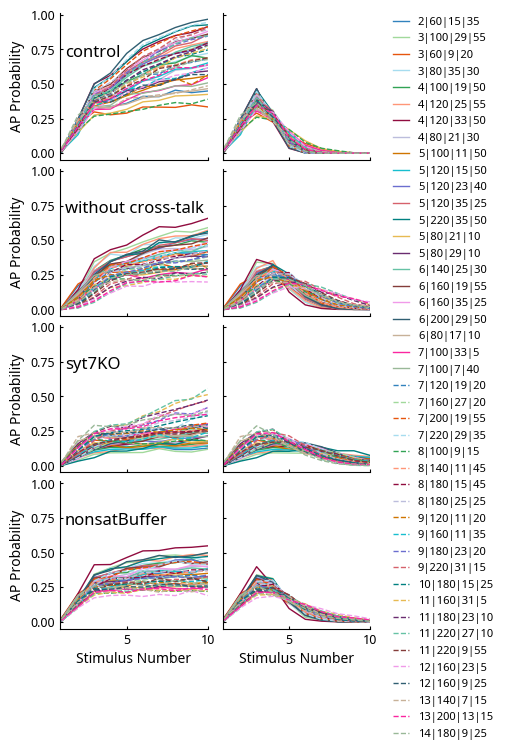

In [2]:
f, ax = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(4,8))
                     #gridspec_kw={'width_ratios': [5, 2]})
f.subplots_adjust(wspace=0.1, hspace=0.06)

ls = ['-', '--']
lw = 1
ISI, nAP = 20, 10
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    for j,design in enumerate(designs[:]):
        # label = str([int(a) for a in re.findall(r'\d+', design)[:-2]])[1:-1]
        st = stinfo['d']
        # tt = stinfo['tt']
        #print(stlabel)
        # inf = os.path.join(resultPath, st, design, tt+'apTimes.dat')

        if stlabel == 'without cross-talk':
            design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(resultPath, st, design, 'CA3p.pk')
        label = '|'.join(list(getSimInfo(design, skip=0).values())[:-2])
        apProb, ap1Prob = getAPprob(ca3p)

        ## AP Probability
        ax[i,0].plot(range(1,11), apProb, lw=lw, linestyle=ls[int(j/22)], 
                   color=cpall[j%22], label=label)
        ax[i,0].set_ylabel('AP Probability', fontsize=10)

        ## 1st AP
        ax[i,1].plot(range(1, nAP+1), ap1Prob, lw=lw, linestyle=ls[int(j/22)],
                     color=cpall[j%22], label=label)

    ax[i,0].set_xlim(0.9,10)
    # ax[i,0].set_ylim(0,1)
    # ax[i,0].set_yticks([0, 0.5, 1.0])

    ax[i,1].set_xlim(0.9,10)
    # ax[i,1].set_ylim(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10)
    # ax[i,1].set_yticks(np.arange(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10+0.0001, 0.1))

    ax[i,0].text(1.2, 0.7, stlabel, fontsize=12)

ax[0,1].legend(frameon=False, ncol=1, handlelength=1.4, fontsize=8,
               loc='upper right', bbox_to_anchor=(1.9, 1.04))
ax[-1,0].set_xlabel("Stimulus Number", fontsize=10)
ax[-1,1].set_xlabel("Stimulus Number", fontsize=10)
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=9)

# plt.savefig(os.path.join(figPath, f'ap_probability.svg'), 
#             dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Number of vesicles to elicit an AP

In [3]:
design = designs[0]
simType = 'without cross-talk'

In [4]:
def get_nrel_to_ap(design, simType):
    RRP = getSimInfo(design, 'RRP', skip=0)
    if simType == 'without cross-talk':
        design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]

    ## Get CA3p spike times
    ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, 'CA3p.pk')
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)
        CA3p_sptimes = ca3['CA3p_spikes']
    # print(CA3p_sptimes)

    ## Get vesicle release times
    resultDir = os.path.join(dataPath, simTypes[simType]['d'], design)

    inf = os.path.join(resultDir, simTypes[simType]['v'].format(RRP))
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)
        # print(vesData.keys())
        
    if simType == 'control':
        vrel_times = [[float(val)*1000 for val in vals] for vals in vesData[RRP]]
        # vrel_times = vrel_times[:50] ##### For testing
    else:
        seeds = len(vesData['AZ1']['sync'])
        vrel_times = [[] for _ in range(seeds)]
        for i in range(seeds):
            for az in list(vesData.keys()):
                for k in vesData[az].keys():
                    vrel_times[i] += [float(a)*1000 for a in vesData[az][k][i]] # Convert to ms

    vrel_times = [np.sort(v) for v in vrel_times]
    # print(len(vrel_times), vrel_times)

    ## Get number of vesicle till first AP
    trials = len(CA3p_sptimes)
    rel_to_ap = []
    for tr in list(range(trials)):
        if len(CA3p_sptimes[tr]) > 0:
            sptime = CA3p_sptimes[tr][0]
            rel_to_ap.append(int(np.sum(vrel_times[tr ] < sptime)))


    return np.mean(rel_to_ap), np.std(rel_to_ap)

get_nrel_to_ap(design, simType)

(np.float64(2.051), np.float64(0.7525948445212737))

## plotting individual changes

In [5]:
_nrel_to_ap = {}
for simType in simTypes:
    temp = []
    for design in designs:
        temp.append(get_nrel_to_ap(design, simType))
    _nrel_to_ap[simType] = np.array(temp).T[0]
    _nrel_to_ap[f'err_{simType}'] = np.array(temp).T[1]

nrel_to_ap = pd.DataFrame(_nrel_to_ap)

In [6]:
nrel_to_ap = pd.DataFrame(_nrel_to_ap)
nrel_to_ap.head()

,control,err_control,without cross-talk,err_without cross-talk,syt7KO,err_syt7KO,nonsatBuffer,err_nonsatBuffer
0,2.0970,0.744037,2.0510,0.752595,1.570439,0.630447,2.045500,0.737177
1,2.3605,0.835188,2.2675,0.784821,1.486860,0.591111,2.195000,0.760904
2,1.9995,0.722841,1.9730,0.717824,1.704727,0.660641,1.946339,0.712849
3,2.2915,0.797200,2.2060,0.767831,1.616580,0.647675,2.121500,0.739417
4,2.3195,0.815733,2.1540,0.793904,1.610375,0.634554,2.157000,0.785080


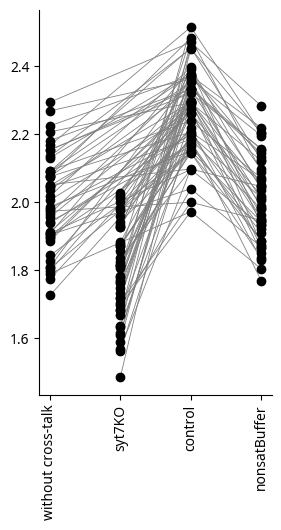

In [7]:
def change_plot(df, key=0, order=None, color='black', lc='gray', lw=1, axis=None):
    """
    Plots changes in a dataframe with lines connecting points.

    Args:
        df (pd.DataFrame): DataFrame containing the data to plot.
        key (int or str, optional): Column to use as the reference point for connecting lines. Defaults to 0.
        order (list, optional): Order of columns to plot. Defaults to None.
        axis (matplotlib.axes._axes.Axes, optional): Axis to plot on. Defaults to None.
        color (str or list, optional): Color of the points. Defaults to black.
        lc (str, optional): Line color. Defaults to gray.
        lw (float, optional): Line width. Defaults to 1.

    Raises:
        ValueError: If length of color list does not match number of columns in dataframe.
        ValueError: If key is not a valid column index or name.

    Returns:
        None
    """
    # Create a new axis if none is provided
    if not axis:
        _, axis = plt.subplots(figsize=(3, 5))

    # Set default line color if none is provided
    if lc is None:
        lc = 'gray'

    # Reorder dataframe columns if order is provided
    if order:
        df = df[order]

    ncols = len(df.columns)

    # Handle point color
    if color is None:
        color = ['black'] * ncols
    elif isinstance(color, str):
        color = [color] * ncols
    elif isinstance(color, list):
        if len(color) != ncols:
            raise ValueError("Length of color list must match number of columns in dataframe")

    # Handle key
    if isinstance(key, int):
        if key >= ncols:
            raise ValueError("Key must be less than number of columns in dataframe")
    elif isinstance(key, str):
        if key not in df.columns:
            raise ValueError("Key must be a column in the dataframe")
        key = df.columns.get_loc(key)

    # Plotting points
    for i, col in enumerate(df.columns):
        axis.scatter([i] * len(df), df[col], label=col, color=color[i], zorder=10)
        axis.set_xticks(range(len(df.columns)))
        axis.set_xticklabels(df.columns, rotation=90)

    # Plotting lines
    other_cols = list(range(ncols))
    other_cols.remove(key)

    for i in range(len(df)):
        for j in other_cols:
            axis.plot([key, j], [df.iloc[i, key], df.iloc[i, j]], color=lc, linewidth=lw)

    # Hide top and right spines
    axis.spines[['top', 'right']].set_visible(False)
    plt.show()

order = ['without cross-talk', 'syt7KO', 'control', 'nonsatBuffer']
change_plot(nrel_to_ap, key='control', order=order, axis=None, lc='gray', lw=0.6)

# AP probability

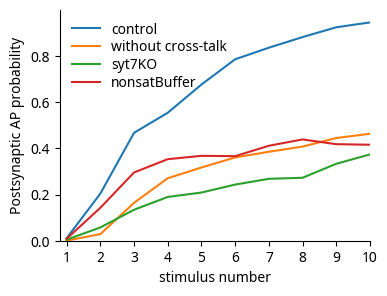

In [10]:
design = designs[25]
fig, ax = plt.subplots(1, figsize=(4,3))

for simType in simTypes.keys():
    if simType == 'without cross-talk':
        _design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], _design, 'CA3p.pk')
    else:
        ca3p = os.path.join(dataPath, simTypes[simType]['d'], design, 'CA3p.pk')
    
    with open(ca3p, "rb") as infile:
        ca3 = pk.load(infile)

    apProb, ap1Prob = getAPprob(ca3p)
    ax.plot(range(1,11), apProb, label=simType)
    ax.set_ylabel("Postsynaptic AP probability")
    ax.set_xlabel("stimulus number") # spike number, vlines for spikes instead of ticks
    ax.set_xlim([0.8, 10])
    ax.set_xticks(range(1,11))
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8])
    ax.legend(frameon=False, labelspacing=0.2)
    ax.spines[["right", "top"]].set_visible(False)
    # axis.spines["top"].set_visible(False)
    # print(ca3.keys())

plt.savefig(os.path.join(figPath, f'ap_probability_single_design.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()